# A+ (Adjusted ANR) Super-Resolution

In [1]:
# Setup: resolve repo root, add to sys.path, and define paths
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'src' / 'anr_patch.py').exists():
            return p
    return start

HERE = Path.cwd().resolve()
REPO_ROOT = find_repo_root(HERE)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print('REPO_ROOT =', REPO_ROOT)

# Paths and config
SCALE = 2  # choose 2, 3, or 4 to match your data
DATA = REPO_ROOT / 'data'
CHECKPOINTS = REPO_ROOT / 'checkpoints'
OUTPUTS = REPO_ROOT / 'outputs'
TRAIN_LR_DIR = DATA / f'degraded_lr/LR_x{SCALE}'
TRAIN_HR_DIR = DATA / f'input_hr/HR_x{SCALE}'
TEST_LR_DIR  = DATA / f'target_lr/LR_x{SCALE}'
TEST_HR_DIR  = DATA / f'target_hr/HR_x{SCALE}'
CKPT_PATH    = CHECKPOINTS / f'anr_aplus_x{SCALE}.pkl'
OUT_DIR      = OUTPUTS / f'anr_aplus_x{SCALE}'
CHECKPOINTS.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('TRAIN_LR_DIR =', TRAIN_LR_DIR)
print('TRAIN_HR_DIR =', TRAIN_HR_DIR)
print('TEST_LR_DIR  =', TEST_LR_DIR)
print('TEST_HR_DIR  =', TEST_HR_DIR)
print('CKPT_PATH    =', CKPT_PATH)
print('OUT_DIR      =', OUT_DIR)


REPO_ROOT = C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv
TRAIN_LR_DIR = C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\data\degraded_lr\LR_x2
TRAIN_HR_DIR = C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\data\input_hr\HR_x2
TEST_LR_DIR  = C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\data\target_lr\LR_x2
TEST_HR_DIR  = C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\data\target_hr\HR_x2
CKPT_PATH    = C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\checkpoints\anr_aplus_x2.pkl
OUT_DIR      = C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\outputs\anr_aplus_x2


In [2]:
from src.anr_patch import APlusConfig, train_aplus, save_model, load_model

FORCE_TRAIN = False
cfg = APlusConfig(scale=SCALE, patch_size=7, step=3, n_anchors=1024, pca_dim=30, ridge_lambda=1e-2, rng_seed=42)

if FORCE_TRAIN or not CKPT_PATH.exists():
    model = train_aplus(str(TRAIN_LR_DIR), str(TRAIN_HR_DIR), cfg)
    save_model(model, str(CKPT_PATH))
    print('Trained and saved:', CKPT_PATH)
else:
    model = load_model(str(CKPT_PATH))
    print('Loaded existing checkpoint:', CKPT_PATH)


Loaded existing checkpoint: C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\checkpoints\anr_aplus_x2.pkl


In [3]:
from src.anr_patch import run_inference_dir
run_inference_dir(str(TEST_LR_DIR), str(CKPT_PATH), str(OUT_DIR))
print('Predictions saved to:', OUT_DIR)


Predictions saved to: C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\outputs\anr_aplus_x2


In [ ]:
import cv2
from pathlib import Path as _Path
from src.anr_patch import sr_anr

cfg_dict = dict(scale=SCALE, patch_size=7, step=3, n_anchors=1024, pca_dim=30, ridge_lambda=1e-2, rng_seed=42)
lr_name = 'your_image.png'  
lr_path = TEST_LR_DIR / lr_name
lr_img = cv2.imread(str(lr_path), cv2.IMREAD_COLOR)  # BGR
if lr_img is None:
    raise FileNotFoundError(lr_path)
hr_rgb = sr_anr(
    lr_img,
    str(CKPT_PATH),
    train_lr_dir=str(TRAIN_LR_DIR),
    train_hr_dir=str(TRAIN_HR_DIR),
    cfg_dict=cfg_dict,
    input_bgr=True,
)
out_path = OUT_DIR / ( _Path(lr_name).stem + '_Aplus.png')
cv2.imwrite(str(out_path), cv2.cvtColor(hr_rgb, cv2.COLOR_RGB2BGR))
print('Saved:', out_path)


Ảnh LR: C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\data\target_lr\LR_x3\img_002_SRF_3_LR.png
GT HR : C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\data\target_hr\HR_x3\img_002_SRF_3_HR.png
CKPT   : C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\checkpoints\anr_aplus_x3.pkl
Đã lưu: C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\outputs\anr_aplus_x3\img_002_SRF_3_LR_Aplus.png


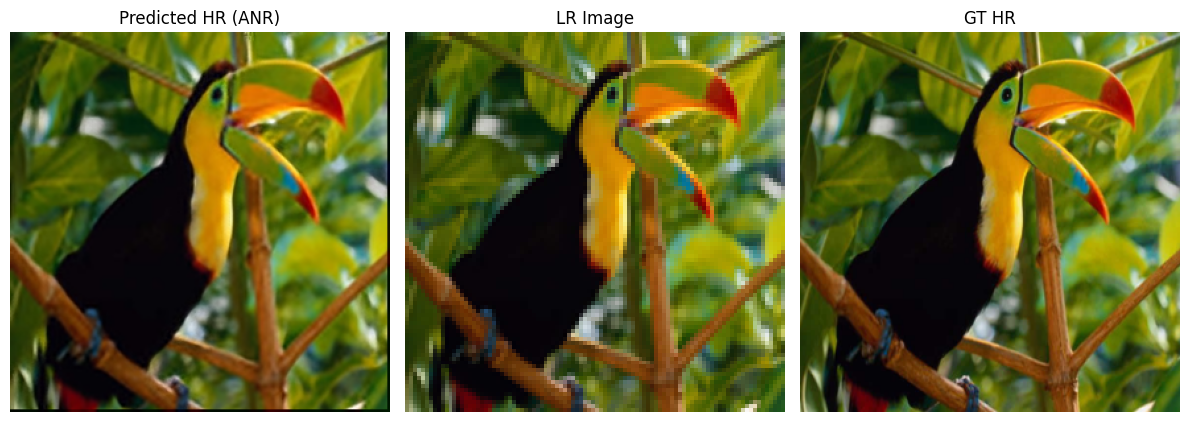

In [1]:
# Bước 1: Chọn scale và thiết lập đường dẫn
from pathlib import Path as _Path
import sys, os, cv2, matplotlib.pyplot as plt

try:
    REPO_ROOT
except NameError:
    def _find_repo_root(start: _Path) -> _Path:
        for p in [start, *start.parents]:
            if (p / 'src' / 'anr_patch.py').exists():
                return p
        return start
    REPO_ROOT = _find_repo_root(_Path.cwd().resolve())
    if str(REPO_ROOT) not in sys.path:
        sys.path.insert(0, str(REPO_ROOT))

SCALE_TEST = 3  
LR_IMG_PATH = REPO_ROOT / 'data' / f'target_lr/LR_x{SCALE_TEST}' / 'img_002_SRF_3_LR.png'
HR_GT_PATH = REPO_ROOT / 'data' / f'target_hr/HR_x{SCALE_TEST}' / 'img_002_SRF_3_HR.png'
TRAIN_LR_DIR_S = REPO_ROOT / 'data' / f'degraded_lr/LR_x{SCALE_TEST}'
TRAIN_HR_DIR_S = REPO_ROOT / 'data' / f'input_hr/HR_x{SCALE_TEST}'
CKPT_S = REPO_ROOT / 'checkpoints' / f'anr_aplus_x{SCALE_TEST}.pkl'
OUT_DIR_S = REPO_ROOT / 'outputs' / f'anr_aplus_x{SCALE_TEST}'
OUT_DIR_S.mkdir(parents=True, exist_ok=True)
print('Ảnh LR:', LR_IMG_PATH)
print('GT HR :', HR_GT_PATH)
print('CKPT   :', CKPT_S)

# Bước 2: Đọc ảnh LR (BGR)
lr_bgr = cv2.imread(str(LR_IMG_PATH), cv2.IMREAD_COLOR)
if lr_bgr is None:
    raise FileNotFoundError(LR_IMG_PATH)

# Bước 3: Suy luận bằng sr_anr (tự train nếu thiếu checkpoint)
from src.anr_patch import sr_anr
cfg_dict = dict(scale=SCALE_TEST, patch_size=7, step=3, n_anchors=1024, pca_dim=30, ridge_lambda=1e-2, rng_seed=42)
pred_hr_rgb = sr_anr(
    lr_bgr,
    str(CKPT_S),
    train_lr_dir=str(TRAIN_LR_DIR_S),
    train_hr_dir=str(TRAIN_HR_DIR_S),
    cfg_dict=cfg_dict,
    input_bgr=True,
)

# Bước 4: Lưu kết quả
out_path = OUT_DIR_S / 'img_002_SRF_3_LR_Aplus.png'
cv2.imwrite(str(out_path), cv2.cvtColor(pred_hr_rgb, cv2.COLOR_RGB2BGR))
print('Đã lưu:', out_path)

# Bước 5 (tuỳ chọn): Hiển thị so sánh Predicted HR / LR / GT HR
lr_rgb = cv2.cvtColor(lr_bgr, cv2.COLOR_BGR2RGB)
hr_gt_bgr = cv2.imread(str(HR_GT_PATH), cv2.IMREAD_COLOR)
hr_gt_rgb = cv2.cvtColor(hr_gt_bgr, cv2.COLOR_BGR2RGB) if hr_gt_bgr is not None else None
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes[0].imshow(pred_hr_rgb); axes[0].set_title('Predicted HR (ANR)'); axes[0].axis('off')
axes[1].imshow(lr_rgb);      axes[1].set_title('LR Image');          axes[1].axis('off')
if hr_gt_rgb is not None:
    axes[2].imshow(hr_gt_rgb); axes[2].set_title('GT HR'); axes[2].axis('off')
else:
    axes[2].imshow(pred_hr_rgb); axes[2].set_title('GT HR (not found)'); axes[2].axis('off')
plt.tight_layout(); plt.show()
